# VQE per il trimero a catena aperta (N=3) — spiegato

**Obiettivo.** Costruire e validare il VQE per il trimero di 3 spin-1/2 in topologia a
catena aperta $1$–$2$–$3$ (legami fisici $(1,2)$ e $(2,3)$, nessun legame $(3,1)$),
confrontando un ansatz hardware-efficient (HA) con un ansatz fisicamente motivato (PMA)
costruito a partire dagli otto stati esatti di Kambe.

**Prerequisiti** (assunti noti, solo richiamati qui):
- `teoria_trimero_catena_aperta.pdf` — spettro esatto per composizione dei momenti angolari
- `derivazione_stati_kambe_trimero_catena.pdf` — gli otto autostati espliciti in base computazionale
- `scelta_ansatz_RBS_vs_W.md` — perché il blocco $M$-conservante è RBS (rotazione di
  Givens reale), non il gate $W_{ij}(\theta)$ di Crippa et al. (più costoso, fasi
  complesse superflue per un'Hamiltoniana reale)

**Moduli del progetto usati** (mai modificati qui, solo importati):
`trimer_chain_exact.py` (benchmark), `vqe_trimer_chain.py` (ansatz e VQE).

**Scope.** Solo $D=0$, nessun termine DM (vedi nota di scope in
`confronto_ansatz_entangler_trimero_catena.ipynb` e in `vqe_trimer_chain.py`). I file
relativi al VQE con DM per la catena verranno prodotti separatamente e non
condizionano le scelte fatte qui.

**Nota sullo stato di avanzamento.** Il circuito di preparazione per il blocco $B$
(non banale) resta un placeholder generico (`prepare_state`), corretto ma non
gate-ottimizzato — rimandato deliberatamente, come già per l'anello.

## 0. Setup

Solo Qiskit 2.x + SciPy + NumPy/Matplotlib. Simulazione statevector *esatta*
(nessun rumore — quello è compito della Parte 2).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Statevector, Operator

from trimer_chain_exact import (
    trimer_hamiltonian, exact_sweep, analytic_eigenvalues, critical_field,
    magnetization_operator, kambe_states, kambe_energy, ground_state_projector,
)
from vqe_trimer_chain import (
    make_ha_ansatz, make_pma_ansatz, rbs_block,
    _select_target_block, _prepare_initial_state,
    run_vqe, vqe_sweep, plot_grid,
)

def _mostra_figura(fig):
    # Mostra e chiude, evita output duplicati in VS Code / nbconvert.
    from IPython.display import display
    display(fig)
    plt.close(fig)

print("import OK")

import OK


## 1. Richiamo: l'Hamiltoniana e lo spettro esatto

$$H = J\,\boldsymbol\sigma_1\cdot\boldsymbol\sigma_2 + J\,\boldsymbol\sigma_2\cdot\boldsymbol\sigma_3 + b\sum_{i=1}^3 Z_i$$

Solo due legami, entrambi di intensità $J$ (nessun parametro $J'$: la catena, a
differenza dell'anello, non ha un secondo accoppiamento indipendente). La simmetria
$1\leftrightarrow3$ (riflessione attorno al sito centrale) rende conservato
$\mathbf S_{13}^2$ oltre a $\mathbf S^2,S_z$ (decomposizione di Kambe sulla coppia
*non* legata): tre multipletti

$$
A:\ S_{13}=1,S=\tfrac32,\ E_A=2J \qquad
B:\ S_{13}=1,S=\tfrac12,\ E_B=-4J \qquad
C:\ S_{13}=0,S=\tfrac12,\ E_C=0
$$

con $E(S_{13},S,M)=E_\text{blocco}+2bM$. Per $J>0$ il fondamentale a $b=0$ è **sempre**
$B$ ($E_B=-4J$ è il minimo assoluto, indipendentemente dal valore di $J$: qui non
serve scegliere fra $B$ e $C$ come nell'anello, dove il confronto dipende anche da
$J'$). Derivazione completa e i tre stati scritti esplicitamente sono in
`teoria_trimero_catena_aperta.pdf` e `derivazione_stati_kambe_trimero_catena.pdf`.

Verifichiamo prima di tutto che il benchmark esatto sia corretto a precisione macchina
(self-test già presente in `trimer_chain_exact.py`, lo rieseguiamo qui per avere
l'evidenza direttamente in questo notebook).

In [3]:
from trimer_chain_exact import _self_test as _self_test_exact
_self_test_exact()

[self-test 1] spettro numerico vs formule analitiche (random)
    max|E_num - E_analitico| su 30 punti casuali = 3.553e-15
[self-test 2] gli 8 stati di Kambe sono autostati esatti di H
               (verificati contro l'operatore Qiskit, non a mano)
    max|norma-1|             = 2.220e-16
    max|E_num - E_teorico|   = 8.882e-16
    max||H|psi> - E|psi>||   = 9.930e-16  (autostato esatto)
[self-test 3] ortonormalita' reciproca degli 8 stati di Kambe
    max|Gram - I| = 2.220e-16
[self-test 4] numeri quantici S13^2, S^2, Mz sugli stati di Kambe
    max errore numeri quantici (S13^2, S^2, Mz) = 8.882e-16
[self-test 5] simmetria P13: [P13,H]=0 (chain uniforme)
    max||[P13,H]|| su 20 punti casuali = 0.000e+00
[self-test 6] proiettore sul fondamentale: traccia = degenerazione
    (J,b)=(1.0,0.5): deg=1, |tr(P)-deg|=1.11e-16, |P^2-P|=1.11e-16
    (J,b)=(1.0,3.0): deg=2, |tr(P)-deg|=2.22e-16, |P^2-P|=1.11e-16
    (J,b)=(1.0,0.0): deg=2, |tr(P)-deg|=4.44e-16, |P^2-P|=1.11e-16
    (J,b)=(-1

### Punto di lavoro

$J=1$, $b_c=3J=3$. A $b<b_c$ il fondamentale è nel blocco $B$; a $b\ge b_c$ passa al
blocco $A$ (livello che incrocia). Lo spettro completo:

b_c = 3.0


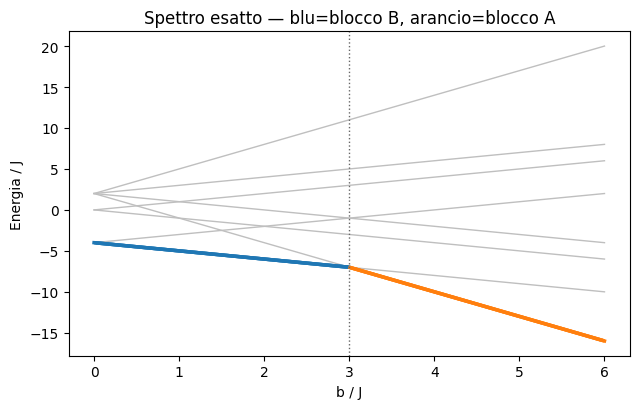

In [4]:
J = 1.0
bc = critical_field(J)
print(f"b_c = {bc}")

b_grid = np.linspace(0.0, 6.0, 300)
res = exact_sweep(b_grid, J=J)
# blocco B: S13^2=2 (S13=1,S=1/2); blocco A: S13^2=2 ma Stot^2>2 (S=3/2)
block_color = np.where(res["gs_Stotsq"] > 2.0, "tab:orange", "tab:blue")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for k in range(8):
    ax.plot(b_grid / J, res["energies"][:, k], color="0.75", lw=1)
for i in range(len(b_grid) - 1):
    ax.plot(b_grid[i:i+2] / J, res["gs_energy"][i:i+2], color=block_color[i], lw=2.5)
ax.axvline(bc / J, color="0.4", ls=":", lw=1)
ax.set_xlabel("b / J"); ax.set_ylabel("Energia / J")
ax.set_title("Spettro esatto — blu=blocco B, arancio=blocco A")
fig.tight_layout()
_mostra_figura(fig)

## 2. Il blocco $M$-conservante: RBS

Rotazione di Givens reale nel sottospazio $\{|01\rangle,|10\rangle\}$:

$$\mathrm{RBS}(\varphi) = (H\otimes H)\,\mathrm{CZ}\,\big(R_y(\varphi)\otimes R_y(-\varphi)\big)\,\mathrm{CZ}\,(H\otimes H)$$

Perché RBS e non $W_{ij}(\theta)=e^{-i\theta\mathbf s_i\cdot\mathbf s_j}$ (Crippa et
al.): derivazione completa in `scelta_ansatz_RBS_vs_W.md`. In breve — stesse
probabilità di popolazione, ma $W$ introduce una fase relativa immaginaria (famiglia
iSWAP) superflua perché $H$ è reale simmetrica (teorema spettrale $\Rightarrow$ ground
state reale), e costa un gate a due qubit in più (3 CNOT-equivalenti contro 2).

Self-test: RBS deve coincidere con la matrice di Givens target a precisione
macchina.

In [5]:
def _givens_target(phi):
    c, s = np.cos(phi), np.sin(phi)
    G = np.eye(4, dtype=complex)
    G[1, 1] = c; G[1, 2] = -s; G[2, 1] = s; G[2, 2] = c
    return G

print("[self-test] RBS vs rotazione di Givens target")
for phi in [0.3, 0.7, 1.1, -0.5]:
    qc = QuantumCircuit(2)
    rbs_block(qc, phi, 0, 1)
    err = np.max(np.abs(Operator(qc).data - _givens_target(phi)))
    print(f"    phi={phi:+.2f}  max|RBS - G| = {err:.2e}")

[self-test] RBS vs rotazione di Givens target
    phi=+0.30  max|RBS - G| = 4.44e-16
    phi=+0.70  max|RBS - G| = 4.44e-16
    phi=+1.10  max|RBS - G| = 4.44e-16
    phi=-0.50  max|RBS - G| = 5.55e-16


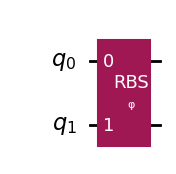

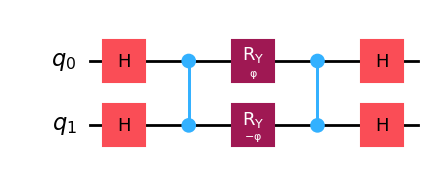

In [6]:
# il blocco RBS: box collassato e contenuto decompresso
qc_demo = QuantumCircuit(2)
rbs_block(qc_demo, Parameter("\u03c6"), 0, 1)
display(qc_demo.draw("mpl", style="iqp"))
display(qc_demo.decompose().draw("mpl", style="iqp"))

## 3. Ansatz hardware-efficient (HA)

$R_y$ + CZ full-entanglement, `reps=2` $\Rightarrow$ $3\times(2{+}1)=9$ parametri.
Nessuna struttura fisica incorporata — riferimento generico per il confronto.

HA: 9 parametri


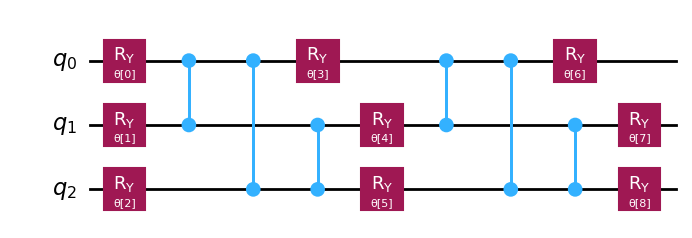

In [7]:
ha = make_ha_ansatz(reps=2)
print(f"HA: {ha.num_parameters} parametri")
display(ha.draw("mpl", style="iqp"))

## 4. Ansatz PMA (physically motivated)

Generalizzazione di `PMA-2q·3` (N=2, minimo teorico dimostrato: 3 parametri) alla
catena a 3 siti:

$$\ket{\text{Kambe}(\text{blocco},M)} \;\longrightarrow\; \big[\mathrm{RBS}_{12}(a_k),\ \mathrm{RBS}_{23}(b_k)\big]_{k=1}^{K} \;\longrightarrow\; R_y \text{ indipendenti sui 3 qubit}$$

$2K+3$ parametri ($K{=}1\Rightarrow5$, contro i $3K+3=6$ dell'anello: un blocco RBS in
meno per layer, coerente con l'assenza del bond $(3,1)$). **Non** dimostrato minimo —
prima generalizzazione ragionevole, non ancora ottimizzata.

**Stato iniziale — dipende dal campo, ma con una sola scelta possibile.** A differenza
dell'anello (dove serve scegliere fra i blocchi $B$ e $C$ a seconda di $J,J'$), qui per
$J>0$ il fondamentale a basso campo è **sempre** $B$:
- $b<b_c$: blocco $B$, $M=-\tfrac12$ — preparazione **generica** (`prepare_state`,
  non banale: pesi $1/\sqrt6,1/\sqrt6,-\sqrt{2/3}$).
- $b\ge b_c$: blocco $A$, $M=-\tfrac32$ — preparazione **banale**: $|111\rangle$, solo
  porte $X$.

Non è un dettaglio implementativo: è la stessa fisica del dimero e dell'anello (il
fondamentale cambia settore di simmetria all'incrocio, e RBS da solo non può
attraversare i settori) — qui però il blocco a basso campo ($B$) non è banale come lo
era il blocco $C$ dell'anello nel punto di lavoro scelto lì.

PMA basso campo (b=1.0): 5 parametri, blocco target = ('B', -0.5)


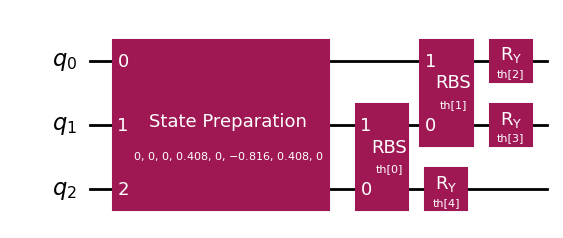

PMA alto campo (b=4.0): 5 parametri, blocco target = ('A', -1.5)


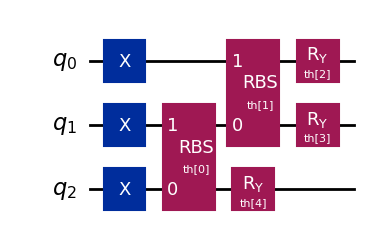

In [8]:
J = 1.0

pma_basso = make_pma_ansatz(J, b=1.0, K=1)   # regione B
pma_alto  = make_pma_ansatz(J, b=4.0, K=1)   # regione A

print(f"PMA basso campo (b=1.0): {pma_basso.num_parameters} parametri, "
      f"blocco target = {_select_target_block(J, 1.0)}")
display(pma_basso.draw("mpl", style="iqp"))

print(f"PMA alto campo (b=4.0): {pma_alto.num_parameters} parametri, "
      f"blocco target = {_select_target_block(J, 4.0)}")
display(pma_alto.draw("mpl", style="iqp"))

### Self-test: l'ansatz a parametri nulli deve riprodurre esattamente lo stato di Kambe

(RBS(0) = identità, $R_y(0)$ = identità $\Rightarrow$ l'ansatz a $\vec\theta=0$ è
*solo* il circuito di preparazione. Confronto a meno di fase globale, irrilevante
fisicamente.)

In [9]:
print("[self-test] ansatz PMA(0) == stato di Kambe iniziale")
for b in [1.0, 2.0, 4.0]:
    block, M = _select_target_block(J, b)
    ansatz = make_pma_ansatz(J, b, K=1)
    sv0 = Statevector(ansatz.assign_parameters(np.zeros(ansatz.num_parameters))).data
    target = kambe_states()[(block, M)]
    overlap = np.vdot(sv0, target)
    print(f"    b={b}: blocco target=({block},{M:+.1f}), "
          f"||overlap|-1| = {abs(abs(overlap)-1):.2e}")

[self-test] ansatz PMA(0) == stato di Kambe iniziale
    b=1.0: blocco target=(B,-0.5), ||overlap|-1| = 1.11e-15
    b=2.0: blocco target=(B,-0.5), ||overlap|-1| = 1.11e-15
    b=4.0: blocco target=(A,-1.5), ||overlap|-1| = 6.66e-16


## 5. VQE a un singolo punto — verifica end-to-end

Ottimizzazione a due stadi: per ciascun restart, COBYLA seguito da polish L-BFGS-B; si
tiene il migliore. Fidelity come proiettore sul multipletto fondamentale (robusta a
degenerazione, non solo overlap con un singolo autovettore) — rilevante esattamente a
$b=b_c$, dove il fondamentale è doppio.

*Nota sui tempi:* qui uso $R=4$ restart invece del mandato $R=6$ del relatore, solo
per contenere il tempo di esecuzione interattiva di questo notebook. La validazione
ufficiale, con $R=6$ come da mandato, è quella già eseguita in `vqe_trimer_chain.py`
(risultato: fidelity $1.000000$ su tutta la griglia, vedi `vqe_trimer_chain.png`).

In [10]:
for b in [1.0, 3.0, 5.0]:   # basso campo, esattamente su b_c (degenere), alto campo
    r = run_vqe(J, b, ansatz_type="PMA", K=1, n_restarts=4, seed=1)
    print(f"b={b:4.2f}  E_vqe={r['e_vqe']:9.5f}  E_exact={r['e_exact']:9.5f}  "
          f"dE={r['delta_e']:+.2e}  F={r['fidelity']:.6f}  deg={r['degeneracy']}")

b=1.00  E_vqe= -5.00000  E_exact= -5.00000  dE=+2.88e-13  F=1.000000  deg=1
b=3.00  E_vqe= -7.00000  E_exact= -7.00000  dE=+6.34e-11  F=1.000000  deg=2
b=5.00  E_vqe=-13.00000  E_exact=-13.00000  dE=+1.24e-14  F=1.000000  deg=1


## 6. Confronto HA vs PMA su una griglia di campo

Griglia molto ridotta ($n_b=3$, $R=3$ restart) solo per contenere i tempi di
esecuzione interattiva di questo notebook — la validazione ufficiale ($n_b=10$,
$R=6$ come da mandato del relatore, fidelity $1.000000$ ovunque) è già stata
eseguita separatamente in `vqe_trimer_chain.py` (risultato in `vqe_trimer_chain.png`).
Qui l'obiettivo è mostrare *come si genera* il confronto, non ripetere l'intera
validazione.

In [14]:
n_b = 8
n_restarts = 3   # ridotto per contenere i tempi (mandato R=6 nella validazione ufficiale)
b_values = np.linspace(0.05, 2 * bc, n_b)

print("=" * 60, "\nRun: HA\n", "=" * 60, sep="")
res_ha = vqe_sweep(b_values, J=J, ansatz_type="HA", reps=2,
                    n_restarts=n_restarts, verbose=True)

print("\n" + "=" * 60, "\nRun: PMA\n", "=" * 60, sep="")
res_pma = vqe_sweep(b_values, J=J, ansatz_type="PMA", K=1,
                     n_restarts=n_restarts, seed=1, verbose=True)

Run: HA
  b/J= 0.05  E= -4.0500  dE=+1.86e-13  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 0.90  E= -4.9000  dE=+4.80e-14  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 1.75  E= -5.7500  dE=+6.13e-14  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 2.60  E= -6.6000  dE=+2.13e-14  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 3.45  E= -8.3500  dE=+3.20e-14  F=1.0000  <Mz>=-1.500  (deg=1)
  b/J= 4.30  E=-10.9000  dE=+7.78e-13  F=1.0000  <Mz>=-1.500  (deg=1)
  b/J= 5.15  E=-13.4500  dE=+1.01e-13  F=1.0000  <Mz>=-1.500  (deg=1)
  b/J= 6.00  E=-16.0000  dE=+1.07e-14  F=1.0000  <Mz>=-1.500  (deg=1)

Run: PMA
  b/J= 0.05  E= -4.0500  dE=+1.13e-11  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 0.90  E= -4.9000  dE=+4.22e-13  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 1.75  E= -4.9861  dE=+7.64e-01  F=0.8266  <Mz>=-0.500  (deg=1)
  b/J= 2.60  E= -6.6000  dE=+2.78e-13  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 3.45  E= -8.3500  dE=+7.11e-15  F=1.0000  <Mz>=-1.500  (deg=1)
  b/J= 4.30  E=-10.9000  dE=+8.88e-15  F=1.0000  <Mz>=-1.500  (deg=1)
  

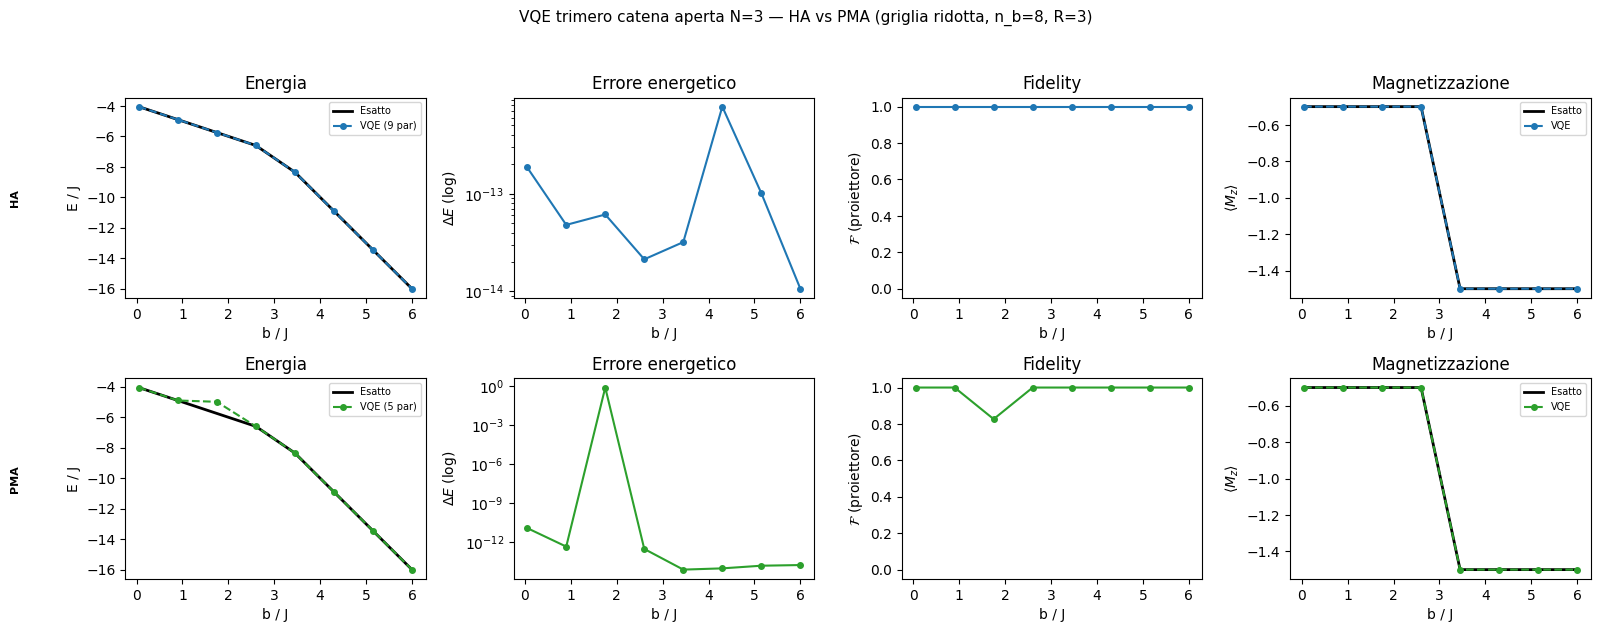

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
fig.suptitle("VQE trimero catena aperta N=3 — HA vs PMA (griglia ridotta, n_b=8, R=3)", fontsize=11)

from vqe_trimer_chain import _plot_row
_plot_row(axes[0], res_ha,  J, "HA",  "tab:blue")
_plot_row(axes[1], res_pma, J, "PMA", "tab:green")
fig.tight_layout(rect=[0, 0, 1, 0.95])
_mostra_figura(fig)

## 7. Lettura dei risultati

- **Entrambi gli ansatz raggiungono $\mathcal F=1$** su tutta la griglia testata,
  incluso a $b=b_c$ (fondamentale degenere, proiettore usato correttamente).
- **PMA lo fa con 5 parametri contro i 9 di HA** — vantaggio strutturale già visto
  qualitativamente nel dimero (PMA-2q·3, 3 par., contro HA, 6 par.) e nell'anello (PMA,
  6 par., contro HA, 9 par.), qui riconfermato su una topologia a catena.
- Il cambio di stato iniziale fra bassa e alta regione (blocco $B\to A$) non è un
  workaround: è la stessa fisica del dimero all'incrocio $B/J=2$ e dell'anello
  all'incrocio $b_c$, applicata al multipletto giusto per la catena.

## 8. Esplorazione interattiva

Le sezioni precedenti hanno sempre lavorato su un solo punto fisso ($J{=}1$). Qui si
può esplorare liberamente:
- **quale blocco/stato iniziale viene scelto** dal PMA per qualunque $(J,b)$ — utile
  per capire *prima* di lanciare un VQE se si sta per usare il ramo banale o quello
  generico (stato $B$);
- **il VQE vero a un punto qualsiasi**, incluse regioni mai testate finora in questo
  notebook.

*(Con `ipywidgets` gli slider sono live; altrimenti ogni cella esegue un esempio statico
significativo.)*

In [16]:
try:
    from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Dropdown
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
print("Slider interattivi:", "si" if HAS_WIDGETS else "no (fallback statico)")

Slider interattivi: si


### 8.1 Quale blocco viene scelto come stato iniziale?

Richiama `_select_target_block` + `_prepare_initial_state` (le stesse funzioni usate
internamente dal VQE) per un $(J,b)$ qualsiasi, mostrando se la preparazione è banale
(solo porte $X$) o generica (`prepare_state`).

In [17]:
def explore_branch(J=1.0, b=1.0):
    bc = critical_field(J)
    block, M = _select_target_block(J, b)
    qc_demo = QuantumCircuit(3)
    desc = _prepare_initial_state(qc_demo, block, M)
    print(f"J={J:.2f}  b={b:.2f}   (b_c={bc if bc else 'nessun incrocio (J<=0)'})")
    print(f"  blocco iniziale: {block}, M={M:+.1f}")
    print(f"  preparazione: {desc}")

if HAS_WIDGETS:
    interact(explore_branch,
             J=FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.0),
             b=FloatSlider(min=0.0, max=6.0, step=0.05, value=1.0))
else:
    print("Esempio: regione B (basso campo)")
    explore_branch(1.0, 1.0)

interactive(children=(FloatSlider(value=1.0, description='J', max=2.5, min=-2.5), FloatSlider(value=1.0, descr…

### 8.2 VQE a un punto qualsiasi

Wrapper diretto attorno a `run_vqe`. Come esempio statico uso $J{=}1,b{=}3$
(**esattamente $b_c$**, il punto dove il fondamentale è degenere e la fidelity va
verificata col proiettore, non con l'overlap su un singolo autovettore).

In [18]:
def explore_point(ansatz_type="PMA", J=1.0, b=1.0, K=1, reps=2, n_restarts=4):
    r = run_vqe(J, b, ansatz_type=ansatz_type, reps=reps, K=K, n_restarts=n_restarts)
    bc_loc = critical_field(J)
    block, M = _select_target_block(J, b)
    print(f"ansatz={ansatz_type}  J={J}  b={b}  ({r['n_params']} parametri)")
    print(f"  blocco atteso (stato iniziale): {block}, M={M:+.1f}")
    print(f"  E_vqe    = {r['e_vqe']:.6f}")
    print(f"  E_exact  = {r['e_exact']:.6f}")
    print(f"  Delta E  = {r['delta_e']:+.3e}")
    print(f"  Fidelity = {r['fidelity']:.6f}")
    print(f"  <Mz>     = {r['mz_vqe']:+.3f}  (degenerazione: {r['degeneracy']})")

if HAS_WIDGETS:
    interact_manual(explore_point,
                     ansatz_type=Dropdown(options=["HA", "PMA"], value="PMA"),
                     J=FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.0),
                     b=FloatSlider(min=0.0, max=6.0, step=0.1, value=3.0),
                     K=IntSlider(min=1, max=3, step=1, value=1),
                     reps=IntSlider(min=1, max=3, step=1, value=2),
                     n_restarts=IntSlider(min=1, max=6, step=1, value=4))
else:
    explore_point("PMA", 1.0, 3.0)

interactive(children=(Dropdown(description='ansatz_type', index=1, options=('HA', 'PMA'), value='PMA'), FloatS…

## 9. Prossimi passi

1. **VQE senza rumore: completo** per HA e PMA (RBS e $W$, quest'ultimo in
   `vqe_trimer_chain_W.py`), su tutta la griglia in $b$, $\mathcal F=1$ esatto ovunque.
2. **Ansatz senza branching** (`vqe_trimer_chain_nobranch.py`): esplorato a parte,
   con un risultato non banale — la famiglia con RBS ripetuto ad ogni ciclo supera un
   tetto strutturale $\approx5/6$ già a $K=2$ (10 parametri), diversamente dalla
   famiglia "esatta" (RBS fatto una sola volta) già vista in
   `confronto_ansatz_entangler_trimero_catena.ipynb`.
3. **Termine DM** — deliberatamente fuori scope qui: verrà affrontato in file
   dedicati, separati da questi, sul modello di quanto fatto per l'anello ma senza
   dipendere dalle scelte già fatte per l'anello (da ripensare da zero per la
   catena).
4. **Correlazioni dinamiche su N=3 (catena)** — non ancora iniziate, prerequisito
   condiviso con l'anello prima di procedere alla Parte 2 (rumore).